In [2]:
import pandas as pd
import subprocess
subprocess.run(['pip', 'install', 'openpyxl'], capture_output=True) 

CompletedProcess(args=['pip', 'install', 'openpyxl'], returncode=0, stdout=b'Requirement already satisfied: openpyxl in /Users/stjia/Documents/research/cloze-encounters/cloze-encounters/lib/python3.13/site-packages (3.1.5)\nRequirement already satisfied: et-xmlfile in /Users/stjia/Documents/research/cloze-encounters/cloze-encounters/lib/python3.13/site-packages (from openpyxl) (2.0.0)\n', stderr=b'\n\x1b[\x1b\x1bnotice\x1b\x1b[1;39;49m]\x1b\x1b A new release of pip is available: \x1b\x1b25.2\x1b\x1b -> \x1b\x1b26.1.1\x1b\n\x1b[\x1b\x1bnotice\x1b\x1b[1;39;49m]\x1b\x1b To update, run: \x1b\x1bpip install --upgrade pip\x1b\n')

## Merge Book (get shares) and Keepa Data (get sales)

In [3]:
book_df = pd.read_csv('/Users/stjia/Documents/research/cloze-encounters/filedata/book-level.csv')
book_df.head()

,index,gpt35_score,gpt4o_score,claude_score,llama8b_score,llama70b_score,gemini_score,book_title,query_id,query,...,author,isbn13,isbn10_v2,isbn13_v2,fiction,nonfiction,count,popularity,count_books,shares
0,0,0.222222,0.111111,0.152778,0.055556,0.194444,0.138889,"10,000-baby-names:-how-to-choose-the-best-name...","10,000-baby-names:-how-to-choose-the-best-name...","Greek, meaning anointed Christian. Chrysantha ...",...,Holly Ivins,9.781905e+12,"['1905410638', '1905410735']","['9781905410637', '9781905410736']",NaN,NaN,72,10-100,9456,0.049157
1,1,0.210526,0.210526,0.157895,0.039474,0.144737,0.223684,"10,000-drinks:-how-to-turn-your-basement-into-...","10,000-drinks:-how-to-turn-your-basement-into-...",[MASK] 1 part 151-Proof Rum 1 part Vodka 1 par...,...,Paul Knorr,9.781403e+12,"['1402742878', '1402792166']","['9781402742873', '9781402792168']",0.0,1.0,76,10-100,2647,0.013760
2,2,0.180556,0.208333,0.180556,0.055556,0.250000,0.208333,"1,000-comic-books-you-must-read,tony-isabella","1,000-comic-books-you-must-read,tony-isabella-...",1965 Non-Pareil Publishing Corp.) Pinned by de...,...,Tony Isabella,9.780897e+12,"['0896899217', '1440213348']","['9780896899216', '9781440213342']",NaN,NaN,72,100-1000,4465,0.023211
3,3,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1000+-little-things-happy-successful-people-do...,1000+-little-things-happy-successful-people-do...,Thank you for buying an authorized edition of ...,...,"Angel Chernoff, Marc Chernoff",9.780526e+12,"['0525542744', '0525504680']","['9780525542742', '9780525504689']",0.0,1.0,1,100-1000,14643,0.076121
4,4,0.177778,0.277778,0.300000,0.088889,0.277778,0.300000,"1000-monuments-of-genius,christopher-e.m.-pearson","1000-monuments-of-genius,christopher-e.m.-pear...","In fact, [MASK] was never besieged or damaged ...",...,Christopher E.M. Pearson,9.781783e+12,"['1783109416', '1844844633']","['9781783109418', '9781844844630']",0.0,1.0,90,0-10,9456,0.049157


In [4]:
df = pd.read_csv('/Users/stjia/Library/CloudStorage/Dropbox-HarvardUniversity/Stella Jia/23.Copyright-LLMs/filedata/final_results_monthyear-keepa.csv')

In [6]:
# Clean isbn13: convert float (e.g. 9.780521e+12) to 13-digit string, drop NaN
df['isbn13_clean'] = (
    pd.to_numeric(df['isbn13'], errors='coerce')
    .dropna()
    .astype('int64')
    .astype(str)
    .str.replace('-', '', regex=False)
    .where(lambda x: x.str.len() == 13)
)

# Export: drop NaN, deduplicate, single column
out = df[['isbn13_clean']].dropna().drop_duplicates()

print(f"Total rows: {len(df)}")
print(f"After dropping NaN: {df['isbn13_clean'].notna().sum()}")
print(f"After deduplication: {len(out)}")

# Export just the clean column (drop NaN rows) as Excel
out_path = '/Users/stjia/Desktop/isbn13_clean.xlsx'
df[['isbn13_clean']].dropna().to_excel(out_path, index=False)
print(f"Exported {df['isbn13_clean'].notna().sum()} rows to {out_path}")

Total rows: 14257
After dropping NaN: 13168
After deduplication: 13131
Exported 13168 rows to /Users/stjia/Desktop/isbn13_clean.xlsx


In [7]:
df_clean = df.dropna(subset=['isbn13_clean']).drop_duplicates(subset=['isbn13_clean']).reset_index(drop=True)
print(f"df:       {len(df):,} rows")
print(f"df_clean: {len(df_clean):,} rows")

df:       14,257 rows
df_clean: 13,131 rows


In [8]:
# add book_df[['shares']] to df merge on isbn13
# add book_df clean isbn13 column if not already present
if 'isbn13_clean' not in book_df.columns:
    book_df['isbn13_clean'] = (
        pd.to_numeric(book_df['isbn13'], errors='coerce')
        .dropna()
        .astype('int64')
        .astype(str)
        .str.replace('-', '', regex=False)
        .where(lambda x: x.str.len() == 13)
    )
df_merged = df_clean.merge(book_df[['isbn13_clean', 'shares']], left_on='isbn13_clean', right_on='isbn13_clean', how='left')

# also add popularity column from book_df to df_merged
if 'popularity' in book_df.columns:
    df_merged = df_merged.merge(book_df[['isbn13_clean', 'popularity']], left_on='isbn13_clean', right_on='isbn13_clean', how='left')

In [9]:
# remove null shares
df_merged = df_merged.dropna(subset=['shares'])
print(f"After merging and dropping null shares: {len(df_merged):,} rows")

After merging and dropping null shares: 12,087 rows


In [10]:
# max publication year
print(f"Max publication year: {df_clean['goodreads_year'].max()}")

Max publication year: 2024.0


Text(0.5, 0, 'Publication Year')

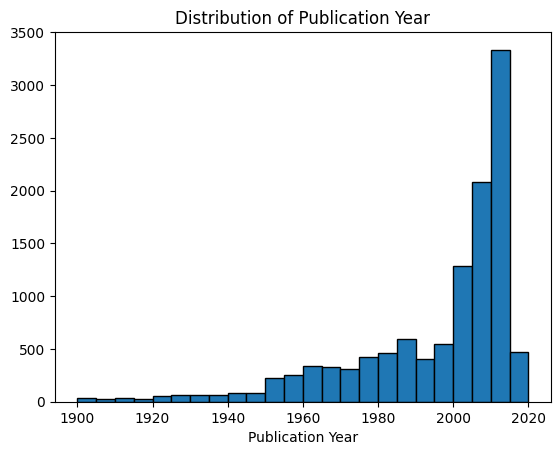

In [11]:
# plot distribution of publication year
import matplotlib.pyplot as plt
plt.hist(df_merged['goodreads_year'], bins=range(1900, 2025, 5), edgecolor='black')
plt.title('Distribution of Publication Year')
plt.xlabel('Publication Year')

In [12]:
df['isbn13'].nunique()

# calc diff in sales rank between two time periods (cross sectional)

# (1) for every model change in [rank / num_ratings / num_reviews] and % change in [] since first and last time period 
# (2) replace name cloze score with that outcome (change in etc)

# issue - change from 100,000 -> 10,000 is differnet than 10 -> 1 
# visualize descriptively these changes

# issue - careful with how pub year impacts rank 
# cutting off new books, maybe add FE

# think more and descriptively about potential issues

# consider trying did

# ----
# for later (overlaps with Keepa though)
# - public dataset of Amazon reviews (CC match books with our sample)
# - using text review to infer demand

13131

In [13]:
df_merged.head()

,num_correct,total_passages,gpt35_turbo_score,map_file_name,title_x,author,isbn13,num_ratings,num_reviews,avg_rating,...,total_llama_correct_70b,total_llama_passages_70b,title,normalized_title_x,month_year,sales_rank,price,isbn13_clean,shares,popularity
0,7,100,0.07000,insightintoieltsstudentsbookupdatededitionthec...,Insight into IELTS Student's Book Updated edit...,"Jakeman, Vanessa, McDowell, Clare",9.780521e+12,75.0,4.0,4.16,...,7,100,NaN,Insight into IELTS Student's Book Updated edit...,"['Jan 2019', 'Feb 2019', 'Mar 2019', 'Apr 2019...","[519883.0, 534904.0, 584180.0, 466902.0, 47365...","[9.62, 9.79, 9.91, 10.28, 9.6, 10.33, 9.89, 10...",9780521011488,0.005479,10-100
1,10,99,0.10101,theshiisofiraqnakashyitzhak,The Shi'is of Iraq,"Nakash, Yitzhak",9.780691e+12,72.0,7.0,3.90,...,15,99,NaN,The Shi'is of Iraq,"['Jan 2019', 'Feb 2019', 'Mar 2019', 'Apr 2019...","[898668.0, 996791.0, 788868.0, 871706.0, 95742...","[9.65, 10.11, 9.43, 9.63, 10.34, 10.01, 10.38,...",9780691115757,0.000998,10-100
2,12,100,0.12000,aworldbeneaththesandsthegoldenageofegyptologyw...,A World Beneath the Sands: The Golden Age of E...,"Wilkinson, Toby",9.781324e+12,880.0,126.0,3.96,...,18,100,NaN,A World Beneath the Sands: The Golden Age of E...,"['Jan 2019', 'Feb 2019', 'Mar 2019', 'Apr 2019...","[338569.0, 321506.0, 374225.0, 341095.0, 31368...","[9.69, 10.08, 10.16, 9.84, 10.19, 9.81, 10.3, ...",9781324006893,0.000317,100-1000
3,0,100,0.00000,angelfallskristinhannah,Angel Falls,Kristin Hannah,9.780308e+12,56068.0,2928.0,3.88,...,0,100,NaN,Angel Falls,"['Jan 2019', 'Feb 2019', 'Mar 2019', 'Apr 2019...","[10000000.0, 20084926.0, 20197748.0, 19674545....","[0.25, 0.23, 0.25, 0.9, 0.09, 0.15, 0.07, 0.04...",9780307756961,0.003582,1000+
4,1,100,0.01000,thespywhocameinfromthecoldlecarrejohn,The Spy Who Came in from the Cold,"Le Carre, John",9.780575e+12,110512.0,6761.0,4.08,...,1,100,NaN,The Spy Who Came in from the Cold,"['Jan 2019', 'Feb 2019', 'Mar 2019', 'Apr 2019...","[811644.0, 836660.0, 792365.0, 663145.0, 69112...","[10.21, 10.06, 10.26, 10.3, 9.76, 9.75, 10.45,...",9780575001497,0.000208,1000+


In [14]:
df_merged.to_csv('/Users/stjia/Documents/research/cloze-encounters/keepa-analysis/data/keepa-merged.csv', index=False)

## Turn Time and Sales Rank into Long Sectional

In [15]:
import ast
from datetime import datetime

def parse_to_datetime_list(val):
    try:
        lst = ast.literal_eval(val) if isinstance(val, str) else val
        return [datetime.strptime(m, '%b %Y') for m in lst]
    except:
        return []

df_merged['month_year_dt'] = df_merged['month_year'].apply(parse_to_datetime_list)
df_merged['first_month']   = df_merged['month_year_dt'].apply(lambda x: x[0]  if len(x) > 0 else None)
df_merged['last_month']    = df_merged['month_year_dt'].apply(lambda x: x[-1] if len(x) > 0 else None)

print(df_merged['first_month'].value_counts())
print()
print(df_merged['last_month'].value_counts())


first_month
2019-01-01    12086
Name: count, dtype: int64

last_month
2025-09-01    12086
Name: count, dtype: int64


In [16]:
df_merged['sales_rank_list'] = df_clean['sales_rank'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

df_merged['first_sales'] = df_merged['sales_rank_list'].apply(lambda x: x[0]  if len(x) > 0 else None)
df_merged['last_sales']  = df_merged['sales_rank_list'].apply(lambda x: x[-1] if len(x) > 0 else None)
df_merged['n_months']    = df_merged['sales_rank_list'].apply(len)

print("List length distribution:")
print(df_merged['n_months'].value_counts().sort_index())
print(f"\nAll same length: {df_merged['n_months'].nunique() == 1}")

List length distribution:
n_months
0         1
81    12086
Name: count, dtype: int64

All same length: False


## Creating Long Data

In [17]:
print(df_merged['in_books3'].value_counts(dropna=False))
print(f"\nTotal books: {len(df_clean)}")

in_books3
False    6199
True     5888
Name: count, dtype: int64

Total books: 13131


In [18]:
import ast
import numpy as np
import pandas as pd

# Remove books with no monthly data
df_clean2 = df_merged[df_merged['n_months'] > 0].copy()
print(f"Dropped {(df_merged['n_months'] == 0).sum()} books with n_months=0, {len(df_clean2)} remaining")

# Parse price into list (num_ratings/num_reviews are scalars, repeated per row)
df_clean2['price_list'] = df_clean2['price'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

rows = []
for idx, row in df_clean2.iterrows():
    months    = row['month_year_dt']
    prices    = row['price_list']
    ranks     = row['sales_rank_list']
    treat     = row['in_books3']
    n_ratings = row['num_ratings']
    n_reviews = row['num_reviews']
    isbn      = row['isbn13_clean']
    years     = row['goodreads_year']
    shares   = row['shares']
    popularity = row['popularity']

    for m, p, r in zip(months, prices, ranks):
        rows.append({
            'book_id':     idx,
            'isbn13':      isbn,
            'date':        m,
            'price':       p,
            'sales_rank':  r,
            'treated':     treat,
            'num_ratings': n_ratings,
            'num_reviews': n_reviews,
            'pub_year':    years,
            'shares':      shares,
            'popularity':  popularity
        })

long = pd.DataFrame(rows)
long['treated']     = pd.to_numeric(long['treated'],    errors='coerce')
long['price']       = pd.to_numeric(long['price'],      errors='coerce')
long['sales_rank']  = pd.to_numeric(long['sales_rank'], errors='coerce')
long['num_ratings'] = pd.to_numeric(long['num_ratings'],errors='coerce')
long['num_reviews'] = pd.to_numeric(long['num_reviews'],errors='coerce')
long['pub_year']    = pd.to_numeric(long['pub_year'],   errors='coerce')
long['shares']      = pd.to_numeric(long['shares'],     errors='coerce')
# long['popularity']  = pd.to_numeric(long['popularity'], errors='coerce')


print(f"Long shape: {long.shape}")
print(f"Date range: {long['date'].min().strftime('%b %Y')} – {long['date'].max().strftime('%b %Y')}")
long.head()

Dropped 1 books with n_months=0, 12086 remaining
Long shape: (978966, 11)
Date range: Jan 2019 – Sep 2025


,book_id,isbn13,date,price,sales_rank,treated,num_ratings,num_reviews,pub_year,shares,popularity
0,0,9780521011488,2019-01-01,9.62,519883.0,False,75.0,4.0,2003.0,0.005479,10-100
1,0,9780521011488,2019-02-01,9.79,534904.0,False,75.0,4.0,2003.0,0.005479,10-100
2,0,9780521011488,2019-03-01,9.91,584180.0,False,75.0,4.0,2003.0,0.005479,10-100
3,0,9780521011488,2019-04-01,10.28,466902.0,False,75.0,4.0,2003.0,0.005479,10-100
4,0,9780521011488,2019-05-01,9.60,473655.0,False,75.0,4.0,2003.0,0.005479,10-100


Text(0, 0.5, 'Frequency')

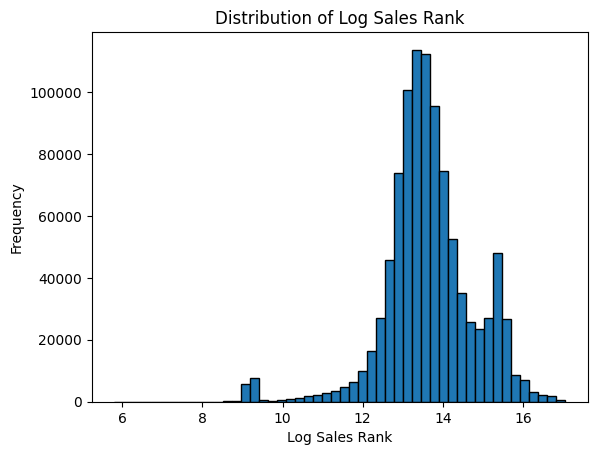

In [19]:
# plot log sales rank
import matplotlib.pyplot as plt
plt.hist(np.log(long['sales_rank'].dropna()), bins=50, edgecolor='black')
plt.title('Distribution of Log Sales Rank')
plt.xlabel('Log Sales Rank')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

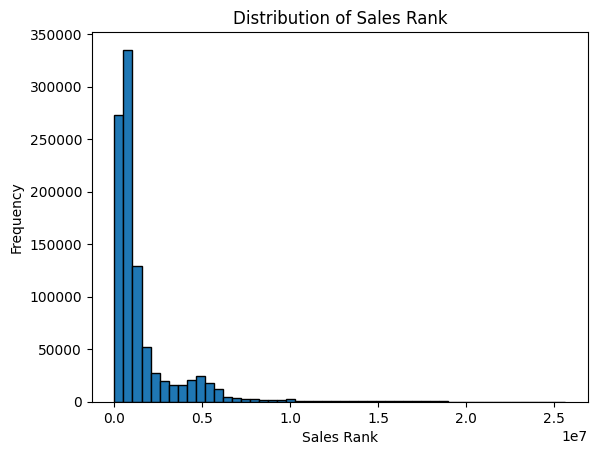

In [16]:
# plot log sales rank
import matplotlib.pyplot as plt
plt.hist(long['sales_rank'].dropna(), bins=50, edgecolor='black')
plt.title('Distribution of Sales Rank')
plt.xlabel('Sales Rank')
plt.ylabel('Frequency')

In [22]:
long.to_csv('/Users/stjia/Documents/research/cloze-encounters/keepa-analysis/data/keepa-merged-long.csv', index=False)

## Look at Specific Book

### check individual book histogram

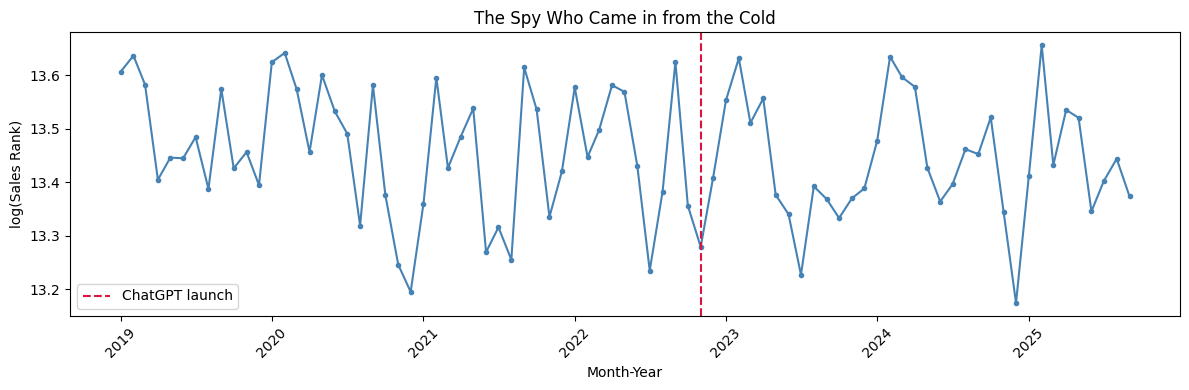

In [18]:
import matplotlib.pyplot as plt

# Pick one book
book = long[long['book_id'] == long['book_id'].iloc[400]].sort_values('date')
long['log_sales_rank'] = np.log(long['sales_rank'].replace(0, np.nan))
title = df_clean2.loc[book['book_id'].iloc[0], 'title_x']

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(book['date'], book['log_sales_rank'], marker='o', ms=3, lw=1.5, color='steelblue')
ax.axvline(pd.Timestamp('2022-11-01'), color='crimson', linestyle='--', lw=1.5, label='ChatGPT launch')
ax.set_xlabel('Month-Year')
ax.set_ylabel('log(Sales Rank)')
ax.set_title(f'{title}')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
# check number of unique book_id in long
print(f"Unique books in long: {long['book_id'].nunique()} (should match df_clean2: {len(df_clean2)})")

Unique books in long: 12086 (should match df_clean2: 12086)


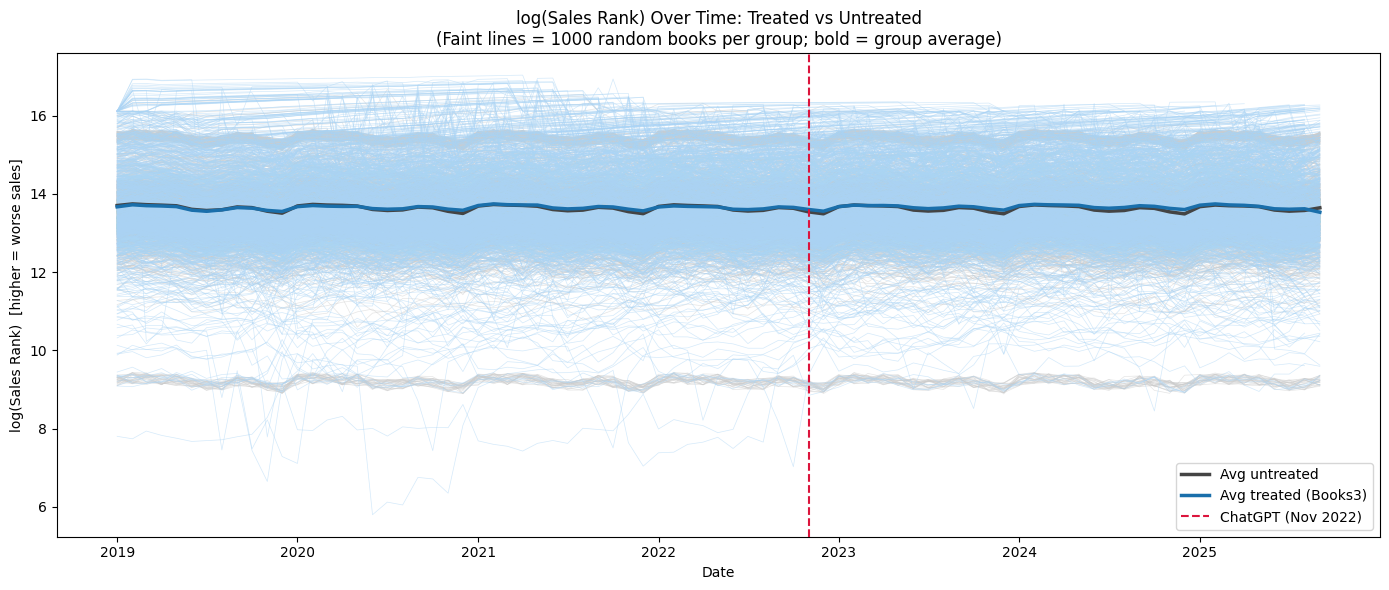

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# filter to just books from 1900-2000
long_sub = long[(long['pub_year'] >= 1500) & (long['pub_year'] <= 2026)].copy()
long_sub['log_sales_rank'] = np.log(long_sub['sales_rank'].replace(0, np.nan))
long_valid = long_sub.dropna(subset=['log_sales_rank', 'treated']).copy()
long_valid['treated'] = long_valid['treated'].map({True: 1, False: 0, 1: 1, 0: 0})

N_SAMPLE = 1000
np.random.seed(50)

fig, ax = plt.subplots(figsize=(14, 6))

for treat_val, ind_color, avg_color, avg_label in [
    (0, '#cccccc', '#444444', 'Avg untreated'),
    (1, '#aad4f5', '#1a6fab', 'Avg treated (Books3)'),
]:
    books = long_valid[long_valid['treated'] == treat_val]['book_id'].unique()
    sample = np.random.choice(books, size=min(N_SAMPLE, len(books)), replace=False)

    for book in sample:
        bdata = long_valid[long_valid['book_id'] == book].sort_values('date')
        ax.plot(bdata['date'], bdata['log_sales_rank'],
                color=ind_color, lw=0.5, alpha=0.5)

    avg = (long_valid[long_valid['treated'] == treat_val]
           .groupby('date')['log_sales_rank'].mean())
    ax.plot(avg.index, avg.values, color=avg_color, lw=2.5, label=avg_label, zorder=5)

ax.axvline(pd.Timestamp('2022-11-01'), color='crimson', linestyle='--',
           lw=1.5, label='ChatGPT (Nov 2022)', zorder=6)
ax.set_xlabel('Date')
ax.set_ylabel('log(Sales Rank)  [higher = worse sales]')
ax.set_title(f'log(Sales Rank) Over Time: Treated vs Untreated\n'
             f'(Faint lines = {N_SAMPLE} random books per group; bold = group average)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
long.columns

Index(['book_id', 'isbn13', 'date', 'price', 'sales_rank', 'treated',
       'num_ratings', 'num_reviews', 'pub_year', 'shares', 'log_sales_rank'],
      dtype='str')

In [21]:
import numpy as np
from linearmodels.iv import IV2SLS

CUTOFF = pd.Timestamp('2022-11-01')

# --- Step 1: avg log sales rank before and after per book ---
long['log_sales_rank'] = np.log(long['sales_rank'].replace(0, np.nan))

pre  = (long[long['date'] <  CUTOFF]
        .groupby('book_id')['log_sales_rank'].mean()
        .rename('avg_log_rank_pre'))
post = (long[long['date'] >= CUTOFF]
        .groupby('book_id')['log_sales_rank'].mean()
        .rename('avg_log_rank_post'))

# --- Step 2: cross-sectional df, one row per book ---
cs = (long.groupby('book_id')
      .agg(treated=('treated', 'first'),
           shares=('shares',  'first'))
      .join(pre).join(post))

cs['delta_log_rank'] = cs['avg_log_rank_post'] - cs['avg_log_rank_pre']
cs['treated']        = pd.to_numeric(cs['treated'], errors='coerce')
cs['shares']         = pd.to_numeric(cs['shares'],  errors='coerce')
cs = cs.dropna(subset=['delta_log_rank', 'treated', 'shares'])

print(f"Cross-sectional sample: {len(cs):,} books")
print(cs[['avg_log_rank_pre', 'avg_log_rank_post', 'delta_log_rank', 'treated', 'shares']].describe().round(4))

# --- Step 3: 2SLS ---
# Outcome:    delta_log_rank  (change in avg log sales rank, post - pre)
# Endogenous: treated         (in_books3)
# Instrument: shares          (share of books from that pub year in Books3)
# No exogenous regressors beyond constant

res_iv = IV2SLS(
    dependent = cs['delta_log_rank'],
    exog      = np.ones(len(cs)),        # constant only
    endog     = cs[['treated']],
    instruments = cs[['shares']]
).fit(cov_type='robust')

print("\n--- 2SLS Results ---")
print(f"β (treated):   {res_iv.params['treated']:.4f}")
print(f"SE:            {res_iv.std_errors['treated']:.4f}")
print(f"p-value:       {res_iv.pvalues['treated']:.3f}")
print(f"95% CI:        [{res_iv.conf_int().loc['treated','lower']:.4f}, {res_iv.conf_int().loc['treated','upper']:.4f}]")
print(f"N:             {res_iv.nobs:,}")
print(f"\n% effect on rank: {(np.exp(res_iv.params['treated']) - 1) * 100:+.2f}%")
print("\nInterpretation: positive β = being in Books3 caused sales rank to rise (demand fell)")

Cross-sectional sample: 11,993 books
       avg_log_rank_pre  avg_log_rank_post  delta_log_rank      shares
count        11993.0000         11993.0000      11993.0000  11993.0000
mean            13.6333            13.6574          0.0241      0.0233
std              1.0934             1.0938          0.3144      0.0290
min              6.8188             7.5326         -4.8802      0.0000
25%             13.0929            13.1032         -0.0209      0.0004
50%             13.5631            13.5776         -0.0027      0.0055
75%             14.1677            14.2095          0.0197      0.0492
max             16.5330            16.3168          3.7430      0.0784

--- 2SLS Results ---
β (treated):   0.1418
SE:            0.0136
p-value:       0.000
95% CI:        [0.1151, 0.1684]
N:             11,993

% effect on rank: +15.23%

Interpretation: positive β = being in Books3 caused sales rank to rise (demand fell)


In [22]:
from linearmodels.iv import IV2SLS
import numpy as np

# Merge popularity onto cs from df_clean2
popularity = df_clean2[['isbn13_clean', 'popularity']].copy()
popularity = popularity.rename(columns={'isbn13_clean': 'isbn13'})

# cs has book_id as index (which is the df_clean2 integer index)
# merge via book_id -> df_clean2 index
cs_pop = cs.copy()
cs_pop['popularity'] = df_clean2.loc[cs_pop.index, 'popularity'].values
cs_pop = cs_pop.dropna(subset=['popularity'])

# Popularity FE: dummies (drop one category as reference)
pop_dummies = pd.get_dummies(cs_pop['popularity'], prefix='pop', drop_first=True).astype(float)
exog_with_fe = pd.concat([pd.Series(1.0, index=cs_pop.index, name='const'), pop_dummies], axis=1)

print(f"Popularity categories: {cs_pop['popularity'].value_counts().to_dict()}")
print(f"Sample after dropping missing popularity: {len(cs_pop):,}")

res_iv_pop = IV2SLS(
    dependent   = cs_pop['delta_log_rank'],
    exog        = exog_with_fe,
    endog       = cs_pop[['treated']],
    instruments = cs_pop[['shares']]
).fit(cov_type='robust')

# --- Compare baseline vs with popularity FE ---
rows_out = []
for label, res, n in [('Baseline (no FE)', res_iv, len(cs)),
                       ('Popularity FE',    res_iv_pop, len(cs_pop))]:
    b  = res.params['treated']
    se = res.std_errors['treated']
    pv = res.pvalues['treated']
    ci = res.conf_int().loc['treated']
    rows_out.append({
        'Model':             label,
        'β (treated)':       f'{b:.4f}',
        'SE':                f'{se:.4f}',
        'p-value':           f'{pv:.3f}',
        '95% CI':            f'[{ci["lower"]:.4f}, {ci["upper"]:.4f}]',
        '% effect on rank':  f'{(np.exp(b) - 1) * 100:+.2f}%',
        'N':                 f'{n:,}',
    })

print("\n--- 2SLS Results ---")
print(pd.DataFrame(rows_out).set_index('Model').T.to_string())

Popularity categories: {'10-100': 3418, '100-1000': 2983, '0-10': 2847, '1000+': 2745}
Sample after dropping missing popularity: 11,993

--- 2SLS Results ---
Model             Baseline (no FE)     Popularity FE
β (treated)                 0.1418            0.1448
SE                          0.0136            0.0143
p-value                      0.000             0.000
95% CI            [0.1151, 0.1684]  [0.1167, 0.1729]
% effect on rank           +15.23%           +15.58%
N                           11,993            11,993


In [ ]:
cs_pop

,treated,shares,avg_log_rank_pre,avg_log_rank_post,delta_log_rank,popularity
book_id,,,,,,
0,False,0.005479,13.103595,13.123233,0.019638,10-100
1,False,0.000998,13.584553,13.561958,-0.022594,10-100
2,False,0.000317,12.688304,12.658346,-0.029957,100-1000
3,True,0.003582,16.383296,15.070444,-1.312852,1000+
4,True,0.000208,13.463941,13.436843,-0.027099,1000+
...,...,...,...,...,...,...
13125,True,0.000483,14.102679,13.990242,-0.112438,0-10
13126,False,0.015148,13.488679,14.447768,0.959089,0-10
13127,False,0.000062,13.152482,13.219627,0.067145,0-10


In [ ]:
res_iv

<class 'linearmodels.compat.statsmodels.Summary'>
"""
                          IV-2SLS Estimation Summary                          
==============================================================================
Dep. Variable:         delta_log_rank   R-squared:                     -0.0035
Estimator:                    IV-2SLS   Adj. R-squared:                -0.0036
No. Observations:               11993   F-statistic:                    108.86
Date:                Sat, Apr 18 2026   P-value (F-stat)                0.0000
Time:                        10:06:59   Distribution:                  chi2(1)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
==============================================================================
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
exog          -0.0446     0.0063    -7.1169     0.0000     -0.0569     -0.0323
treated        0.1418     0.0136     10.434     0.0000      0.1151      0.1684
==============================================================================

Endogenous: treated
Instruments: shares
Robust Covariance (Heteroskedastic)
Debiased: False
"""

In [ ]:
res_iv_pop

IV-2SLS Estimation Summary                          
==============================================================================
Dep. Variable:         delta_log_rank   R-squared:                      0.0049
Estimator:                    IV-2SLS   Adj. R-squared:                 0.0045
No. Observations:               11993   F-statistic:                    146.56
Date:                Sat, Apr 18 2026   P-value (F-stat)                0.0000
Time:                        10:25:05   Distribution:                  chi2(4)
Cov. Estimator:                robust                                         
                                                                              
                              Parameter Estimates                               
================================================================================
              Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------
const           -0.0338     0.0049    -6.8978     0.0000     -0.0434     -0.0242
pop_10-100       0.0105     0.0059     1.7662     0.0774     -0.0012      0.0222
pop_100-1000     0.0014     0.0075     0.1855     0.8529     -0.0133      0.0160
pop_1000+       -0.0683     0.0120    -5.6918     0.0000     -0.0918     -0.0448
treated          0.1448     0.0143     10.110     0.0000      0.1167      0.1729
================================================================================

Endogenous: treated
Instruments: shares
Robust Covariance (Heteroskedastic)
Debiased: False
IVResults, id: 0x31c009590

## Difference in Log Regression

In [24]:
from linearmodels.iv import IV2SLS
import numpy as np

# Build cross-sectional df from df_clean2 using first_sales and last_sales
cs2 = df_clean2[['isbn13_clean', 'in_books3', 'shares', 'first_sales', 'last_sales']].copy()
cs2['first_sales'] = pd.to_numeric(cs2['first_sales'], errors='coerce')
cs2['last_sales']  = pd.to_numeric(cs2['last_sales'],  errors='coerce')
cs2['shares']      = pd.to_numeric(cs2['shares'],      errors='coerce')
cs2['treated']     = cs2['in_books3'].map({True: 1, False: 0, 'True': 1, 'False': 0})

# Outcome: log(last_sales) - log(first_sales) = log(last/first)
cs2 = cs2[(cs2['first_sales'] > 0) & (cs2['last_sales'] > 0)]
cs2['delta_log_rank'] = np.log(cs2['last_sales']) - np.log(cs2['first_sales'])
cs2 = cs2.dropna(subset=['delta_log_rank', 'treated', 'shares'])

print(f"Sample: {len(cs2):,} books")
print(f"Outcome (delta_log_rank) mean: {cs2['delta_log_rank'].mean():.4f}  => {(np.exp(cs2['delta_log_rank'].mean())-1)*100:+.1f}% avg rank change")

res_iv2 = IV2SLS(
    dependent   = cs2['delta_log_rank'],
    exog        = pd.Series(1.0, index=cs2.index, name='const'),
    endog       = cs2[['treated']],
    instruments = cs2[['shares']]
).fit(cov_type='robust')

b  = res_iv2.params['treated']
se = res_iv2.std_errors['treated']
pv = res_iv2.pvalues['treated']
ci = res_iv2.conf_int().loc['treated']

print(f"\n--- IV Results: log(last_sales) - log(first_sales) ---")
print(f"β (treated):        {b:.4f}")
print(f"SE:                 {se:.4f}")
print(f"p-value:            {pv:.3f}")
print(f"95% CI:             [{ci['lower']:.4f}, {ci['upper']:.4f}]")
print(f"% effect on rank:   {(np.exp(b) - 1) * 100:+.2f}%")
print(f"N:                  {res_iv2.nobs:,}")
print(f"\nFirst stage F-stat: {res_iv2.first_stage.diagnostics['f.stat'].iloc[0]:.2f}")

Sample: 10,681 books
Outcome (delta_log_rank) mean: -0.0034  => -0.3% avg rank change

--- IV Results: log(last_sales) - log(first_sales) ---
β (treated):        0.1812
SE:                 0.0206
p-value:            0.000
95% CI:             [0.1407, 0.2216]
% effect on rank:   +19.86%
N:                  10,681

First stage F-stat: 2663.90


In [28]:
from linearmodels.iv import IV2SLS
import numpy as np

# Outcome: log(last_sales) - log(first_sales)
cs2 = df_clean2[['in_books3', 'shares', 'first_sales', 'last_sales', 'popularity']].copy()
cs2['first_sales'] = pd.to_numeric(cs2['first_sales'], errors='coerce')
cs2['last_sales']  = pd.to_numeric(cs2['last_sales'],  errors='coerce')
cs2['shares']      = pd.to_numeric(cs2['shares'],      errors='coerce')
cs2['treated']     = cs2['in_books3'].map({True: 1, False: 0, 'True': 1, 'False': 0})
cs2 = cs2[(cs2['first_sales'] > 0) & (cs2['last_sales'] > 0)]
cs2['delta_log_rank'] = np.log(cs2['last_sales']) - np.log(cs2['first_sales'])
cs2 = cs2.dropna(subset=['delta_log_rank', 'treated', 'shares'])

print(f"Sample: {len(cs2):,} books")
print(f"Mean delta_log_rank: {cs2['delta_log_rank'].mean():.4f}  => {(np.exp(cs2['delta_log_rank'].mean())-1)*100:+.1f}% avg rank change")

# --- Model 1: Baseline ---
res_base = IV2SLS(
    dependent   = cs2['delta_log_rank'],
    exog        = pd.Series(1.0, index=cs2.index, name='const'),
    endog       = cs2[['treated']],
    instruments = cs2[['shares']]
).fit(cov_type='robust')

# --- Model 2: Popularity FE ---
cs2_pop = cs2.dropna(subset=['popularity'])
pop_dummies = pd.get_dummies(cs2_pop['popularity'], prefix='pop', drop_first=True).astype(float)
exog_fe = pd.concat([pd.Series(1.0, index=cs2_pop.index, name='const'), pop_dummies], axis=1)

res_pop = IV2SLS(
    dependent   = cs2_pop['delta_log_rank'],
    exog        = exog_fe,
    endog       = cs2_pop[['treated']],
    instruments = cs2_pop[['shares']]
).fit(cov_type='robust')

# --- Summary table ---
rows_out = []
for label, res, n in [('Baseline',      res_base, len(cs2)),
                       ('Popularity FE', res_pop,  len(cs2_pop))]:
    b  = res.params['treated']
    se = res.std_errors['treated']
    pv = res.pvalues['treated']
    ci = res.conf_int().loc['treated']
    rows_out.append({
        'Model':            label,
        'β (treated)':      f'{b:.4f}',
        'SE':               f'{se:.4f}',
        'p-value':          f'{pv:.7f}',
        '95% CI':           f'[{ci["lower"]:.4f}, {ci["upper"]:.4f}]',
        '% effect on rank': f'{(np.exp(b) - 1) * 100:+.2f}%',
        'N':                f'{n:,}',
    })

print("\n--- IV Results: log(last_sales_rank) - log(first_sales_rank) ---")
print(pd.DataFrame(rows_out).set_index('Model').T.to_string())

Sample: 10,681 books
Mean delta_log_rank: -0.0034  => -0.3% avg rank change

--- IV Results: log(last_sales_rank) - log(first_sales_rank) ---
Model                     Baseline     Popularity FE
β (treated)                 0.1812            0.1805
SE                          0.0206            0.0219
p-value                  0.0000000         0.0000000
95% CI            [0.1407, 0.2216]  [0.1376, 0.2234]
% effect on rank           +19.86%           +19.78%
N                           10,681            10,681
